In [10]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob

from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
df = pd.read_csv("comments.csv")


In [12]:

df.head()

,Comment,Expected_Sentiment
0,I absolutely love this product! Great quality ...,Positive
1,Worst purchase ever. Completely disappointed.,Negative
2,"The service was okay, nothing special.",Neutral
3,Excellent customer support and amazing experie...,Positive
4,Terrible packaging and damaged item.,Negative


In [13]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Comment             20 non-null     object
 1   Expected_Sentiment  20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


In [14]:

df.isnull().sum()

,0
Comment,0
Expected_Sentiment,0


In [15]:
import re

def clean(text):
    text = text.lower()
    text = re.sub(r'http\S+','',text)
    text = re.sub(r'[^a-zA-Z ]','',text)
    return text

df["clean_comment"] = df["Comment"].apply(clean)

In [16]:
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df["tokens"] = df["clean_comment"].apply(word_tokenize)

df["tokens"] = df["tokens"].apply(lambda x:[i for i in x if i not in stop_words])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
def sentiment(text):
    return TextBlob(text).sentiment.polarity

df["Polarity"] = df["clean_comment"].apply(sentiment)

def label(x):
    if x > 0:
        return "Positive"
    elif x < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Polarity"].apply(label)

In [18]:
cv = CountVectorizer(max_features=20)

X = cv.fit_transform(df["clean_comment"])

words = cv.get_feature_names_out()

print(words)

['again' 'and' 'buy' 'completely' 'customer' 'delivery' 'experience' 'for'
 'good' 'is' 'money' 'not' 'product' 'purchase' 'quality' 'service' 'the'
 'this' 'was' 'with']


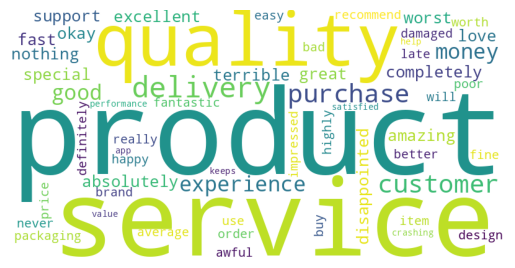

In [19]:
text = " ".join(df["clean_comment"])

wc = WordCloud(width=800,height=400,background_color="white").generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

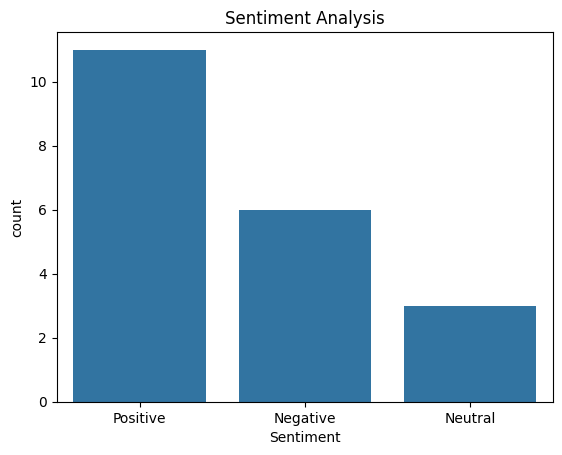

In [20]:
sns.countplot(x="Sentiment",data=df)

plt.title("Sentiment Analysis")

plt.show()